# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos**

O objetivo desta etapa é compreender a estrutura das bases de dados, identificar padrões, avaliar a qualidade das informações disponíveis e gerar hipóteses que orientem as etapas posteriores de pré-processamento e modelagem.

Toda visualização apresentada será acompanhada de interpretação dos resultados e de suas implicações para o projeto de classificação de risco de crédito.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

app_raw = pd.read_csv("application_record.csv")
credit_raw = pd.read_csv("credit_record.csv")

# 1. Visão Geral

Nesta etapa são analisadas as dimensões das bases, os tipos dos atributos e uma amostra inicial dos registros.

Essa avaliação permite compreender a estrutura dos dados antes da aplicação de qualquer tratamento.

In [ ]:
print("Application record:")
print(app_raw.shape)

display(app_raw.head())

app_raw.info()

Application record:
(438557, 18)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [ ]:
print("Credit record:")
print(credit_raw.shape)

display(credit_raw.head())

credit_raw.info()

Credit record:
(1048575, 3)


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


### Interpretação

A base application_record contém informações cadastrais dos clientes, enquanto a base credit_record reúne o histórico mensal de crédito.

Observa-se que a base de crédito possui volume significativamente maior de registros, pois está estruturada no nível cliente-mês, permitindo múltiplas observações para o mesmo cliente ao longo do tempo.

Essa diferença indica que será necessário consolidar o histórico mensal posteriormente para construção da variável alvo.

# 2. Dados Faltantes

In [ ]:
print("Valores ausentes em application_record")
display(
    app_raw.isna()
    .sum()
    .sort_values(ascending=False)
)

print("Valores ausentes em credit_record")
display(
    credit_raw.isna()
    .sum()
    .sort_values(ascending=False)
)

Valores ausentes em application_record


,0
OCCUPATION_TYPE,134203
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
CNT_CHILDREN,0
FLAG_OWN_REALTY,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
AMT_INCOME_TOTAL,0


Valores ausentes em credit_record


,0
ID,0
MONTHS_BALANCE,0
STATUS,0


In [ ]:
qtd_nulos = (
    app_raw["OCCUPATION_TYPE"]
    .isna()
    .sum()
)

perc_nulos = (
    app_raw["OCCUPATION_TYPE"]
    .isna()
    .mean() * 100
)

print(qtd_nulos)
print(f"{perc_nulos:.2f}%")

134203
30.60%


### Interpretação

A análise dos valores ausentes mostra que a principal variável com registros faltantes é OCCUPATION_TYPE.

As demais variáveis da base cadastral não apresentam volume relevante de ausências e a base credit_record não possui valores nulos nas variáveis utilizadas.

### Implicação para o projeto

A variável OCCUPATION_TYPE exigirá tratamento específico na etapa de pré-processamento para evitar perda desnecessária de observações.

# 3. Duplicidades

In [ ]:
print(app_raw.duplicated().sum())

print(app_raw["ID"].duplicated().sum())

print(credit_raw.duplicated().sum())

print(credit_raw["ID"].nunique())

0
47
0
45985


### Interpretação

Não foram encontradas linhas completamente duplicadas na base cadastral.

Entretanto, foram identificados IDs repetidos, situação que merece investigação, pois cada cliente deveria possuir um cadastro único.

Na base credit_record esse comportamento é esperado, pois um mesmo cliente pode aparecer em diversos meses do histórico de crédito.

### Implicação para o projeto

Os IDs duplicados serão investigados e tratados durante o pré-processamento antes da integração das bases.

# 4. Distribuição das Variáveis Categóricas

In [ ]:
categorical_cols = [
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE"
]

for col in categorical_cols:
    display(
        app_raw[col]
        .value_counts(dropna=False)
    )

,count
CODE_GENDER,
F,294440
M,144117


,count
FLAG_OWN_CAR,
N,275459
Y,163098


,count
FLAG_OWN_REALTY,
Y,304074
N,134483


,count
NAME_INCOME_TYPE,
Working,226104
Commercial associate,100757
Pensioner,75493
State servant,36186
Student,17


,count
NAME_EDUCATION_TYPE,
Secondary / secondary special,301821
Higher education,117522
Incomplete higher,14851
Lower secondary,4051
Academic degree,312


,count
NAME_FAMILY_STATUS,
Married,299828
Single / not married,55271
Civil marriage,36532
Separated,27251
Widow,19675


,count
NAME_HOUSING_TYPE,
House / apartment,393831
With parents,19077
Municipal apartment,14214
Rented apartment,5974
Office apartment,3922
Co-op apartment,1539


,count
OCCUPATION_TYPE,
NaN,134203
Laborers,78240
Core staff,43007
Sales staff,41098
Managers,35487
Drivers,26090
High skill tech staff,17289
Accountants,15985
Medicine staff,13520


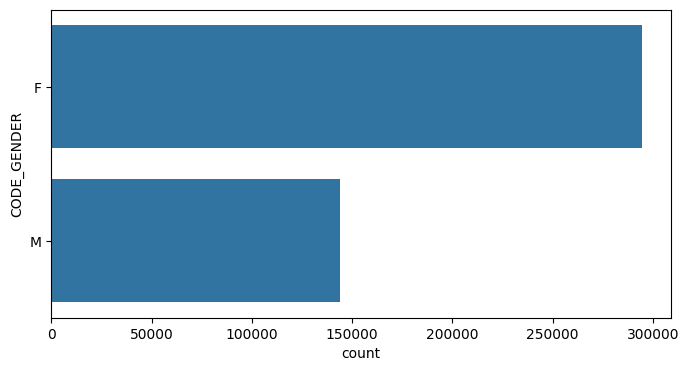

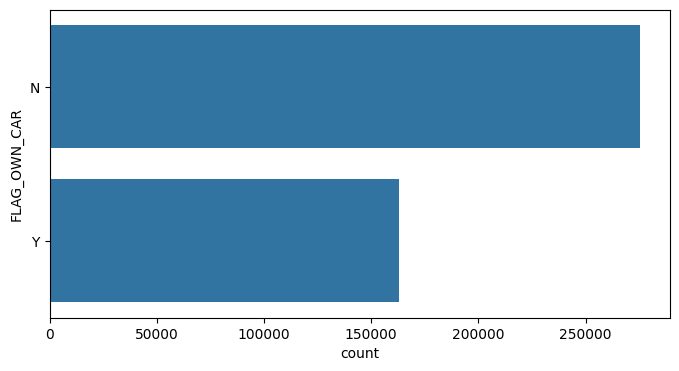

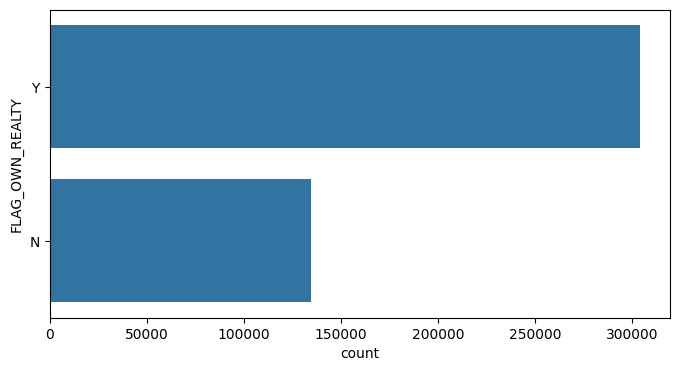

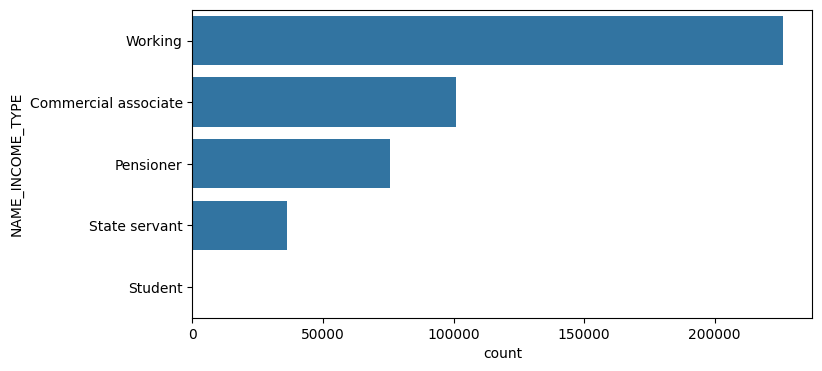

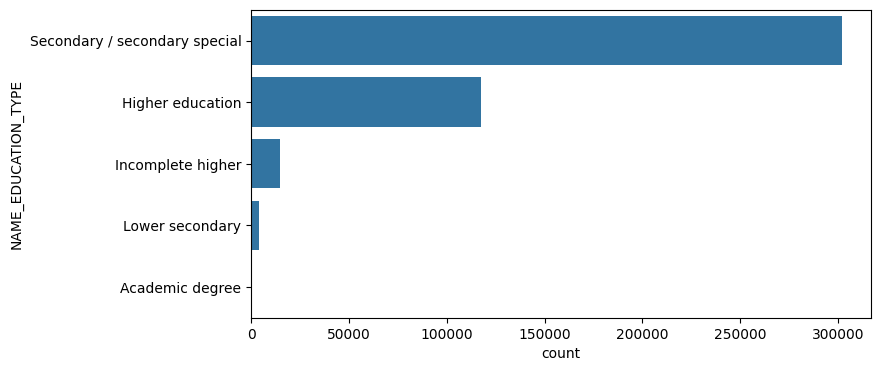

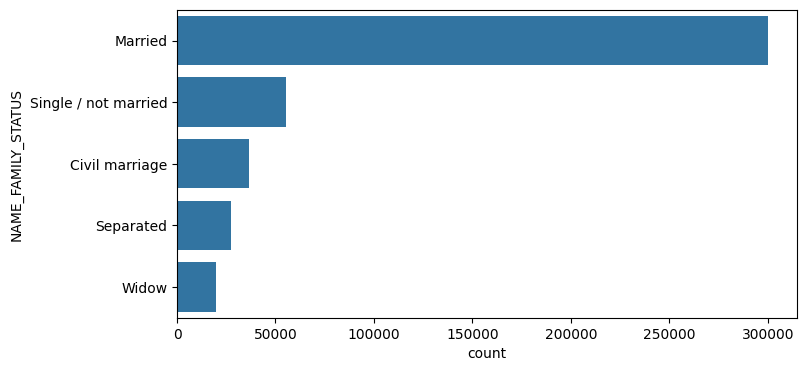

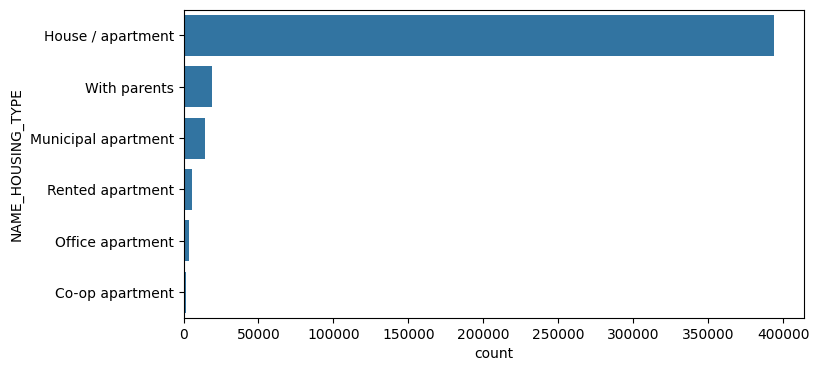

In [ ]:
for col in [
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE"
]:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=app_raw,
        y=col,
        order=app_raw[col].value_counts().index
    )

    plt.show()

### Interpretação

A distribuição das variáveis categóricas revela predominância de clientes do sexo feminino, sem posse de veículo próprio e com imóvel próprio.

Observa-se também maior concentração de clientes classificados como Working, escolaridade Secondary / secondary special, estado civil Married e moradia do tipo House / apartment.

A variável OCCUPATION_TYPE apresenta volume relevante de valores ausentes e concentração em ocupações como Laborers, Core staff, Sales staff e Managers.

### Implicação para o projeto

Essas distribuições ajudam a caracterizar o perfil predominante dos clientes e reforçam a necessidade de tratamento específico para OCCUPATION_TYPE.
`

# 5. Outliers

In [ ]:
numeric_cols = [
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_FAM_MEMBERS"
]

# Estatísticas descritivas
app_raw[numeric_cols].describe()

# Percentis para identificar possíveis valores extremos
app_raw[
    [
        "AMT_INCOME_TOTAL",
        "CNT_CHILDREN",
        "CNT_FAM_MEMBERS"
    ]
].quantile([
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
])

# Maiores rendas observadas
app_raw.sort_values(
    "AMT_INCOME_TOTAL",
    ascending=False
)[
    [
        "ID",
        "AMT_INCOME_TOTAL",
        "NAME_INCOME_TYPE",
        "OCCUPATION_TYPE"
    ]
].head(20)

# Maiores tamanhos de família
app_raw.sort_values(
    "CNT_FAM_MEMBERS",
    ascending=False
)[
    [
        "ID",
        "CNT_CHILDREN",
        "CNT_FAM_MEMBERS",
        "NAME_FAMILY_STATUS"
    ]
].head(20)

# Maiores quantidades de filhos
app_raw.sort_values(
    "CNT_CHILDREN",
    ascending=False
)[
    [
        "ID",
        "CNT_CHILDREN",
        "CNT_FAM_MEMBERS",
        "NAME_FAMILY_STATUS"
    ]
].head(20)

,ID,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS
36388,5105054,19,20.0,Single / not married
20443,5061211,14,15.0,Separated
20442,5061210,14,15.0,Separated
20441,5061207,14,15.0,Separated
208912,5931571,12,14.0,Married
208909,5931568,12,14.0,Married
208911,5931570,12,14.0,Married
208910,5931569,12,14.0,Married
79646,5307274,9,11.0,Civil marriage
79645,5307273,9,11.0,Civil marriage


### Interpretação

Foram identificados valores extremos principalmente nas variáveis AMT_INCOME_TOTAL, CNT_CHILDREN e CNT_FAM_MEMBERS.

A comparação entre os percentis superiores e os valores máximos mostra observações significativamente acima da maior parte da população. Em relação à renda anual, a maioria dos registros está concentrada em faixas muito inferiores ao valor máximo observado. Situação semelhante ocorre para quantidade de filhos e tamanho da família.

Entretanto, a análise individual dos registros indica coerência entre as informações disponíveis. Os clientes com maior quantidade de filhos também apresentam tamanhos familiares compatíveis, não havendo evidências claras de erro de preenchimento.

### Decisão

Manter os registros nesta etapa.

### Justificativa

O objetivo da análise exploratória é compreender os dados e identificar possíveis pontos de atenção para etapas posteriores. Como não foram encontradas inconsistências evidentes, optou-se por preservar os valores observados.

A decisão sobre eventuais transformações, agrupamentos ou tratamentos específicos será realizada no notebook de pré-processamento, onde haverá avaliação mais detalhada do impacto desses registros sobre a modelagem.

In [ ]:
numeric_cols = [
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_FAM_MEMBERS"
]

# Estatísticas descritivas
app_raw[numeric_cols].describe()

# Percentis para identificar possíveis valores extremos
app_raw[
    [
        "AMT_INCOME_TOTAL",
        "CNT_CHILDREN",
        "CNT_FAM_MEMBERS"
    ]
].quantile([
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
])

# Maiores rendas observadas
app_raw.sort_values(
    "AMT_INCOME_TOTAL",
    ascending=False
)[
    [
        "ID",
        "AMT_INCOME_TOTAL",
        "NAME_INCOME_TYPE",
        "OCCUPATION_TYPE"
    ]
].head(20)

# Maiores tamanhos de família
app_raw.sort_values(
    "CNT_FAM_MEMBERS",
    ascending=False
)[
    [
        "ID",
        "CNT_CHILDREN",
        "CNT_FAM_MEMBERS",
        "NAME_FAMILY_STATUS"
    ]
].head(20)

# Maiores quantidades de filhos
app_raw.sort_values(
    "CNT_CHILDREN",
    ascending=False
)[
    [
        "ID",
        "CNT_CHILDREN",
        "CNT_FAM_MEMBERS",
        "NAME_FAMILY_STATUS"
    ]
].head(20)

,ID,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS
36388,5105054,19,20.0,Single / not married
20443,5061211,14,15.0,Separated
20442,5061210,14,15.0,Separated
20441,5061207,14,15.0,Separated
208912,5931571,12,14.0,Married
208909,5931568,12,14.0,Married
208911,5931570,12,14.0,Married
208910,5931569,12,14.0,Married
79646,5307274,9,11.0,Civil marriage
79645,5307273,9,11.0,Civil marriage
